In [1]:
%pip install -qq --upgrade pip
%pip install -qq --upgrade -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import tempfile

import diagrams
from diagrams import Diagram, Cluster, Edge, Node
from diagrams.custom import Custom

from cards import compose_card, compose_text_card

ICONS = "../assets/icons"
CARD_DIR = tempfile.mkdtemp(prefix="cluster-diagram-cards-")
RES = os.path.join(os.path.dirname(os.path.dirname(diagrams.__file__)), "resources")

# A small, deliberately short palette. Only the *primary request path* in the
# Logical Architecture diagram (edge -> workload -> data) gets a dedicated
# hue; every supporting/cross-cutting layer shares one neutral "platform"
# color. Rainbow-per-category borders are a known readability anti-pattern
# (see docs/diagrams/readme.md for the design-review notes that led here).
COLOR = {
    # primary flow (Logical Architecture)
    "edge": "#EA580C",
    "workload": "#DB2777",
    "data": "#0891B2",
    "platform": "#64748B",
    "neutral": "#CBD5E1",
    # hardware diagram
    "home": "#475569",
    "compute": "#2563EB",
    # delivery pipeline stages -- distinct per-stage color is the standard
    # "pipeline" convention (cf. AWS CodePipeline / Step Functions diagrams),
    # not the same thing as category-overload in a single container diagram
    "gitops": "#2563EB",
    "storage": "#CA8A04",
    "secrets": "#DC2626",
    "ops": "#6B7280",
}

HEADER_FS = "22"
LAYER_FS = "16"
NODE_FS = "12"

TOP_GRAPH_ATTR = {
    "fontsize": HEADER_FS,
    "fontname": "Helvetica-Bold",
    "bgcolor": "#F7F8FA",
    "pad": "0.5",
    "splines": "spline",
    "nodesep": "0.45",
    "ranksep": "0.65",
    "dpi": "150",
}

NODE_ATTR = {
    "fontsize": NODE_FS,
    "fontname": "Helvetica",
}

_card_seq = 0


def layer_cluster(label, key, dashed=False, muted=False):
    """The "layer" boundary box. `muted=True` draws a neutral-gray border
    with only the label text tinted by category -- used in diagrams with
    many categories, so grouping boxes don't compete with their contents.
    `muted=False` (default) keeps the border itself colored, appropriate
    for a small, sequential set of categories (e.g. pipeline stages)."""
    pencolor = COLOR["neutral"] if muted else COLOR[key]
    return Cluster(
        label=label,
        graph_attr={
            "bgcolor": "white",
            "pencolor": pencolor,
            "fontcolor": COLOR[key],
            "fontsize": LAYER_FS,
            "fontname": "Helvetica-Bold",
            "style": "dashed,rounded" if dashed else "rounded",
            "penwidth": "1.6" if muted else "2.2",
            "labeljust": "l",
            "margin": "18",
        },
    )


def _new_card_path():
    global _card_seq
    _card_seq += 1
    return os.path.join(CARD_DIR, f"card_{_card_seq:03d}.png")


def icon(label, icon_path, key, **kwargs):
    """One consistent white card (icon + caption + category accent bar) for
    every node, vendored brand icon or Graphviz-bundled alike. Baking the
    caption into the raster avoids Graphviz's image+label box sizing quirks
    for multi-line captions next to non-square source art."""
    out = _new_card_path()
    compose_card(icon_path, label, out, accent=COLOR[key])
    attrs = dict(width="1.3", height="1.69", fixedsize="true", imagescale="true")
    attrs.update(kwargs)
    return Custom("", out, **attrs)


def text_icon(label, key, **kwargs):
    """Same card treatment, for components with no usable official
    icon-only logo (e.g. Tempo, Sealed Secrets) -- a monogram chip instead."""
    out = _new_card_path()
    compose_text_card(label, out, accent=COLOR[key])
    attrs = dict(width="1.3", height="1.69", fixedsize="true", imagescale="true")
    attrs.update(kwargs)
    return Custom("", out, **attrs)


def legend_node():
    label = "──────   request / data flow\n- - - - -   control / secondary interaction"
    return Node(label, shape="plaintext", fontsize="12", fontname="Helvetica")


def vendored(name):
    """A brand icon we fetched into docs/assets/icons/ (see docs/diagrams/readme.md)."""
    return os.path.join(ICONS, name)


def bundled(rel):
    """An icon already shipped inside the installed `diagrams` package."""
    return os.path.join(RES, rel)


# bundled (Graphviz-shipped, official-logo) icon paths, resolved once
NGINX_ICON = bundled("onprem/network/nginx.png")
ISTIO_ICON = bundled("onprem/network/istio.png")
CERTMANAGER_ICON = bundled("onprem/certificates/cert-manager.png")
LETSENCRYPT_ICON = bundled("onprem/certificates/lets-encrypt.png")
QDRANT_ICON = bundled("onprem/database/qdrant.png")
GRAFANA_ICON = bundled("onprem/monitoring/grafana.png")
PROMETHEUS_ICON = bundled("onprem/monitoring/prometheus.png")
ARGOCD_ICON = bundled("onprem/gitops/argocd.png")
GITHUBACTIONS_ICON = bundled("onprem/ci/github-actions.png")
HELM_ICON = bundled("k8s/ecosystem/helm.png")
CRD_ICON = bundled("k8s/others/crd.png")
RASPBIAN_ICON = bundled("generic/os/raspbian.png")
UBUNTU_ICON = bundled("generic/os/ubuntu.png")
ROUTER_ICON = bundled("generic/network/router.png")
FIREWALL_ICON = bundled("generic/network/firewall.png")

## 1. Hardware Architecture

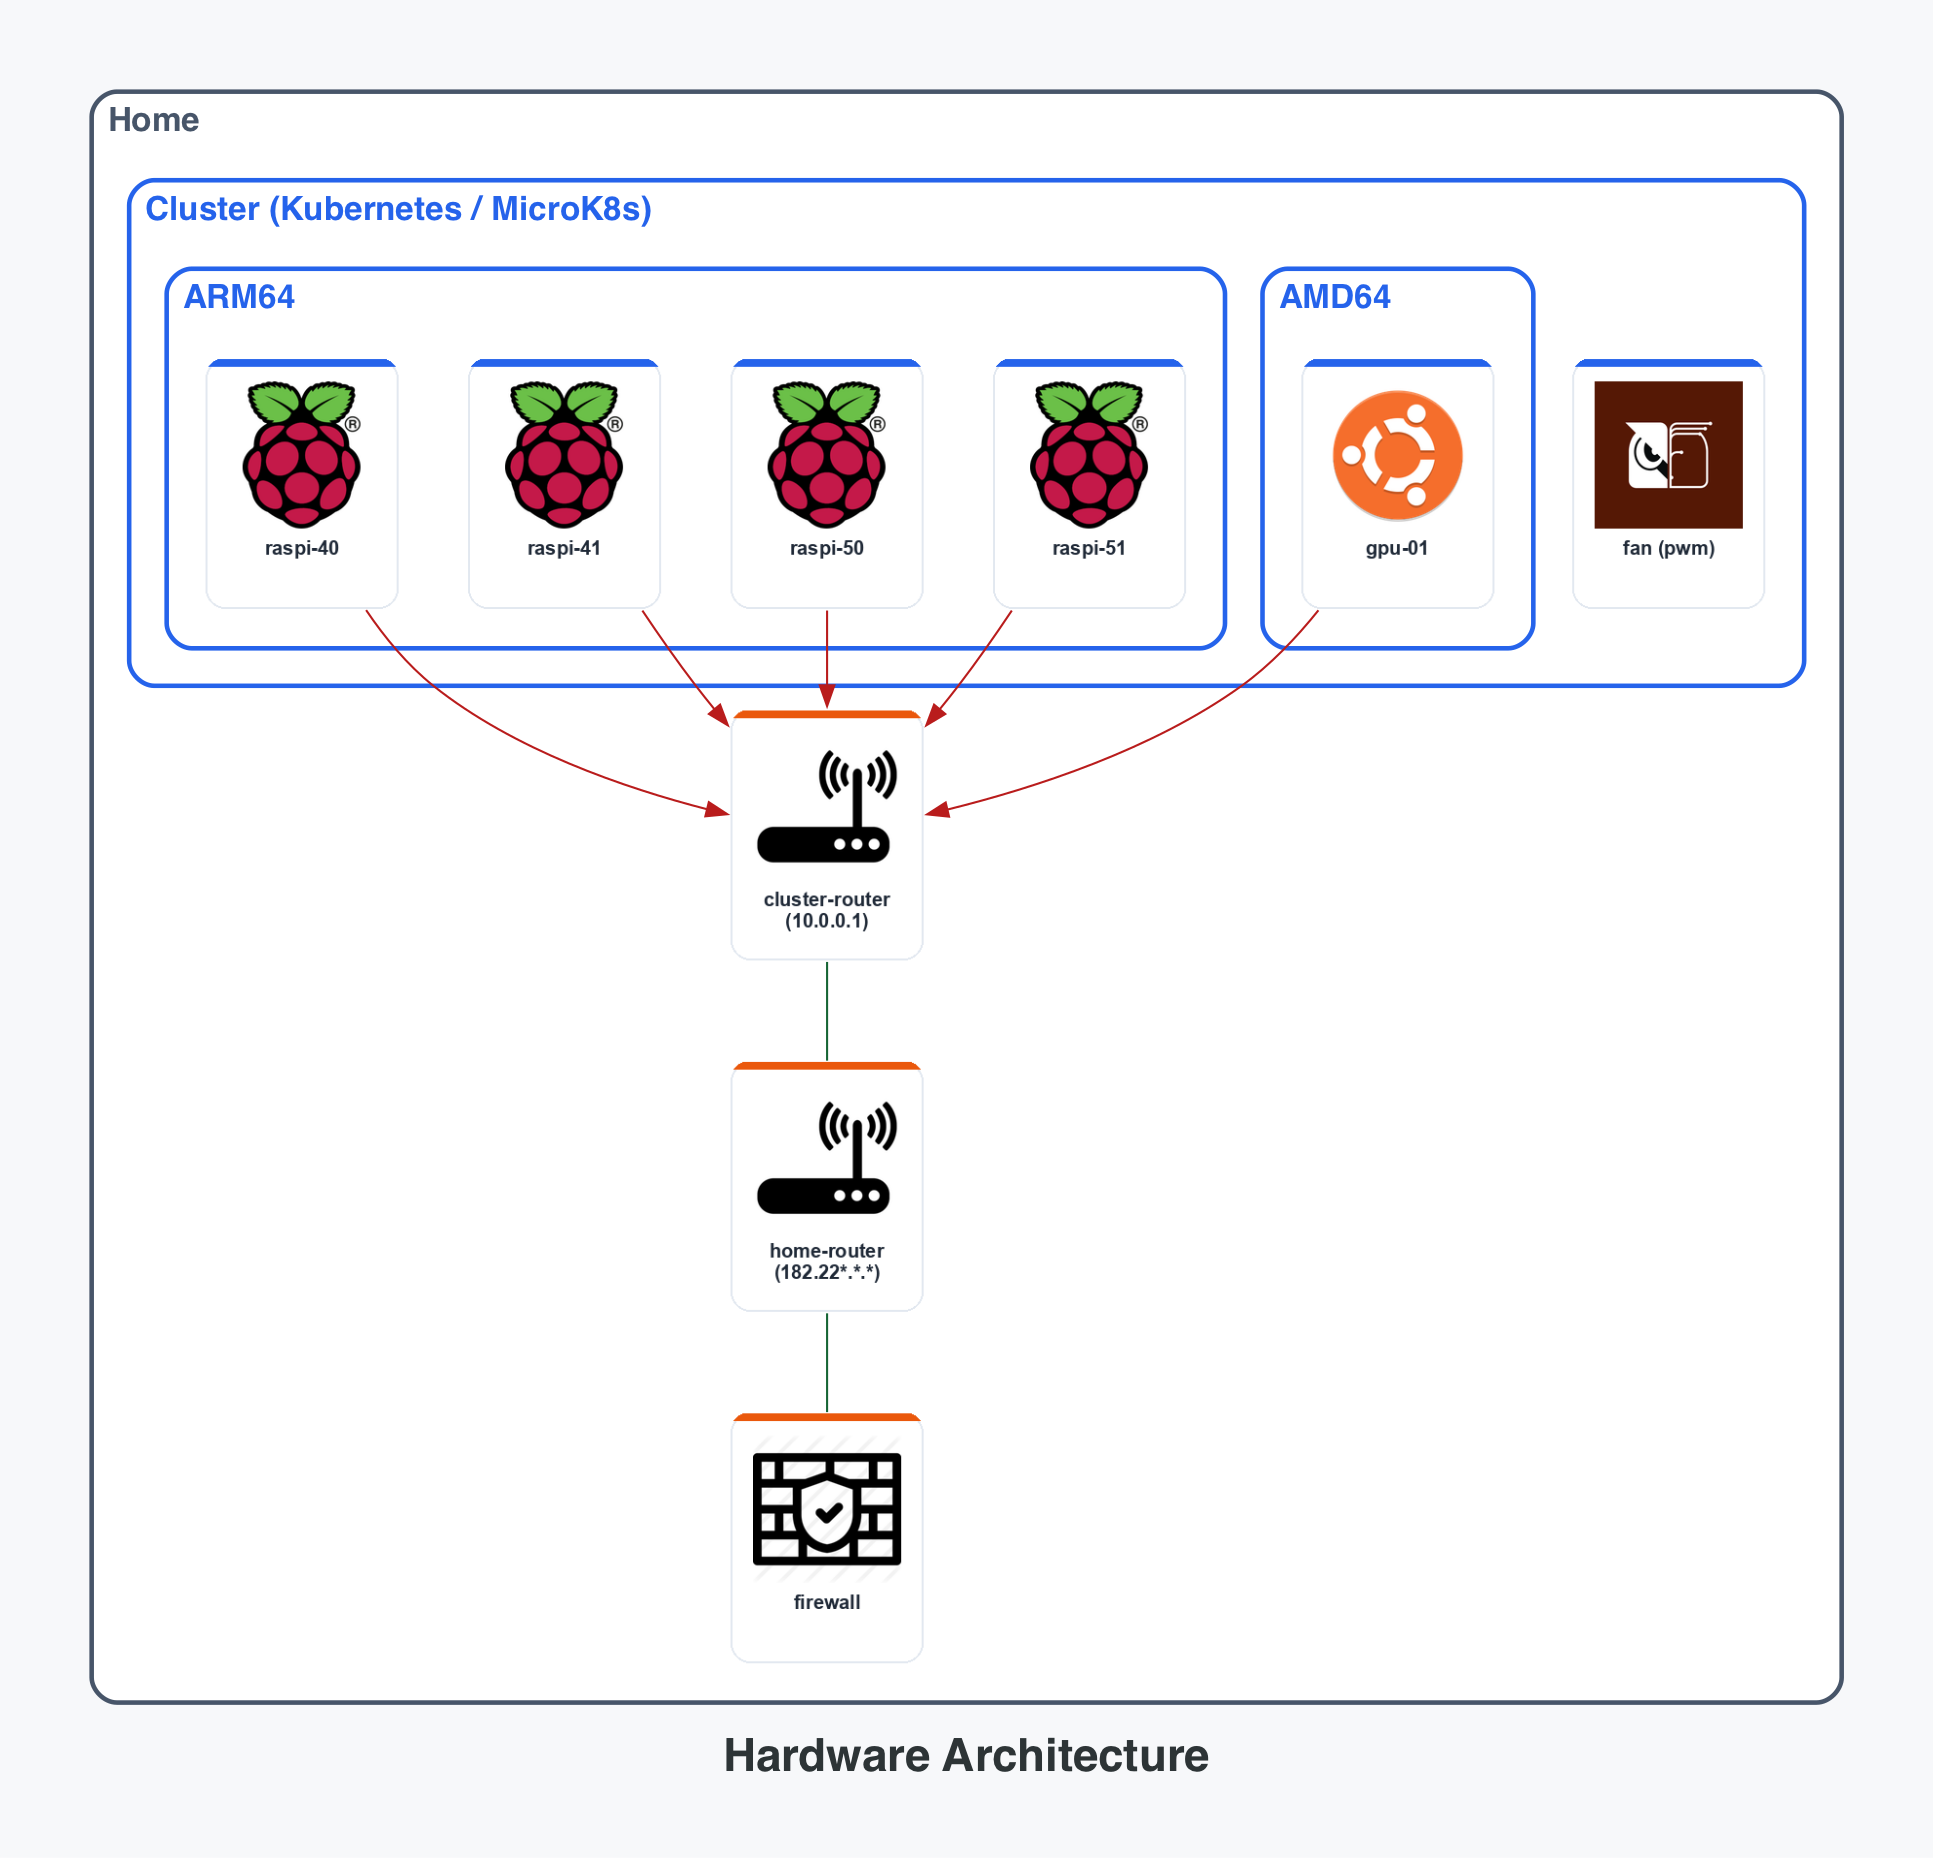

In [3]:
with Diagram(
    name="Hardware Architecture",
    filename="hardware-architecture",
    show=False,
    direction="TB",
    graph_attr=TOP_GRAPH_ATTR,
    node_attr=NODE_ATTR,
) as diag:
    with layer_cluster("Home", "home"):
        with layer_cluster("Cluster (Kubernetes / MicroK8s)", "compute"):
            fan = icon("fan (pwm)", vendored("noctua-fan.png"), "compute")
            with layer_cluster("ARM64", "compute"):
                arms = [
                    icon(f"raspi-{n}", RASPBIAN_ICON, "compute") for n in ("40", "41", "50", "51")
                ]
            with layer_cluster("AMD64", "compute"):
                amds = [icon("gpu-01", UBUNTU_ICON, "compute")]

        cluster_router = icon("cluster-router\n(10.0.0.1)", ROUTER_ICON, "edge")
        home_router = icon("home-router\n(182.22*.*.*)", ROUTER_ICON, "edge")
        firewall = icon("firewall", FIREWALL_ICON, "edge")

    # single-ended arrows for the initiating side; the router<->router/firewall
    # segments are a physical link, not a request/response flow, so they are
    # drawn as plain undirected lines rather than a confusing double-arrow.
    for node in arms + amds:
        node >> Edge(color="#B91C1C") >> cluster_router
    cluster_router >> Edge(color="#166534", arrowhead="none") >> home_router
    home_router >> Edge(color="#166534", arrowhead="none") >> firewall

diag

## 2. Delivery Pipeline (GitOps Flow, L0-L4)

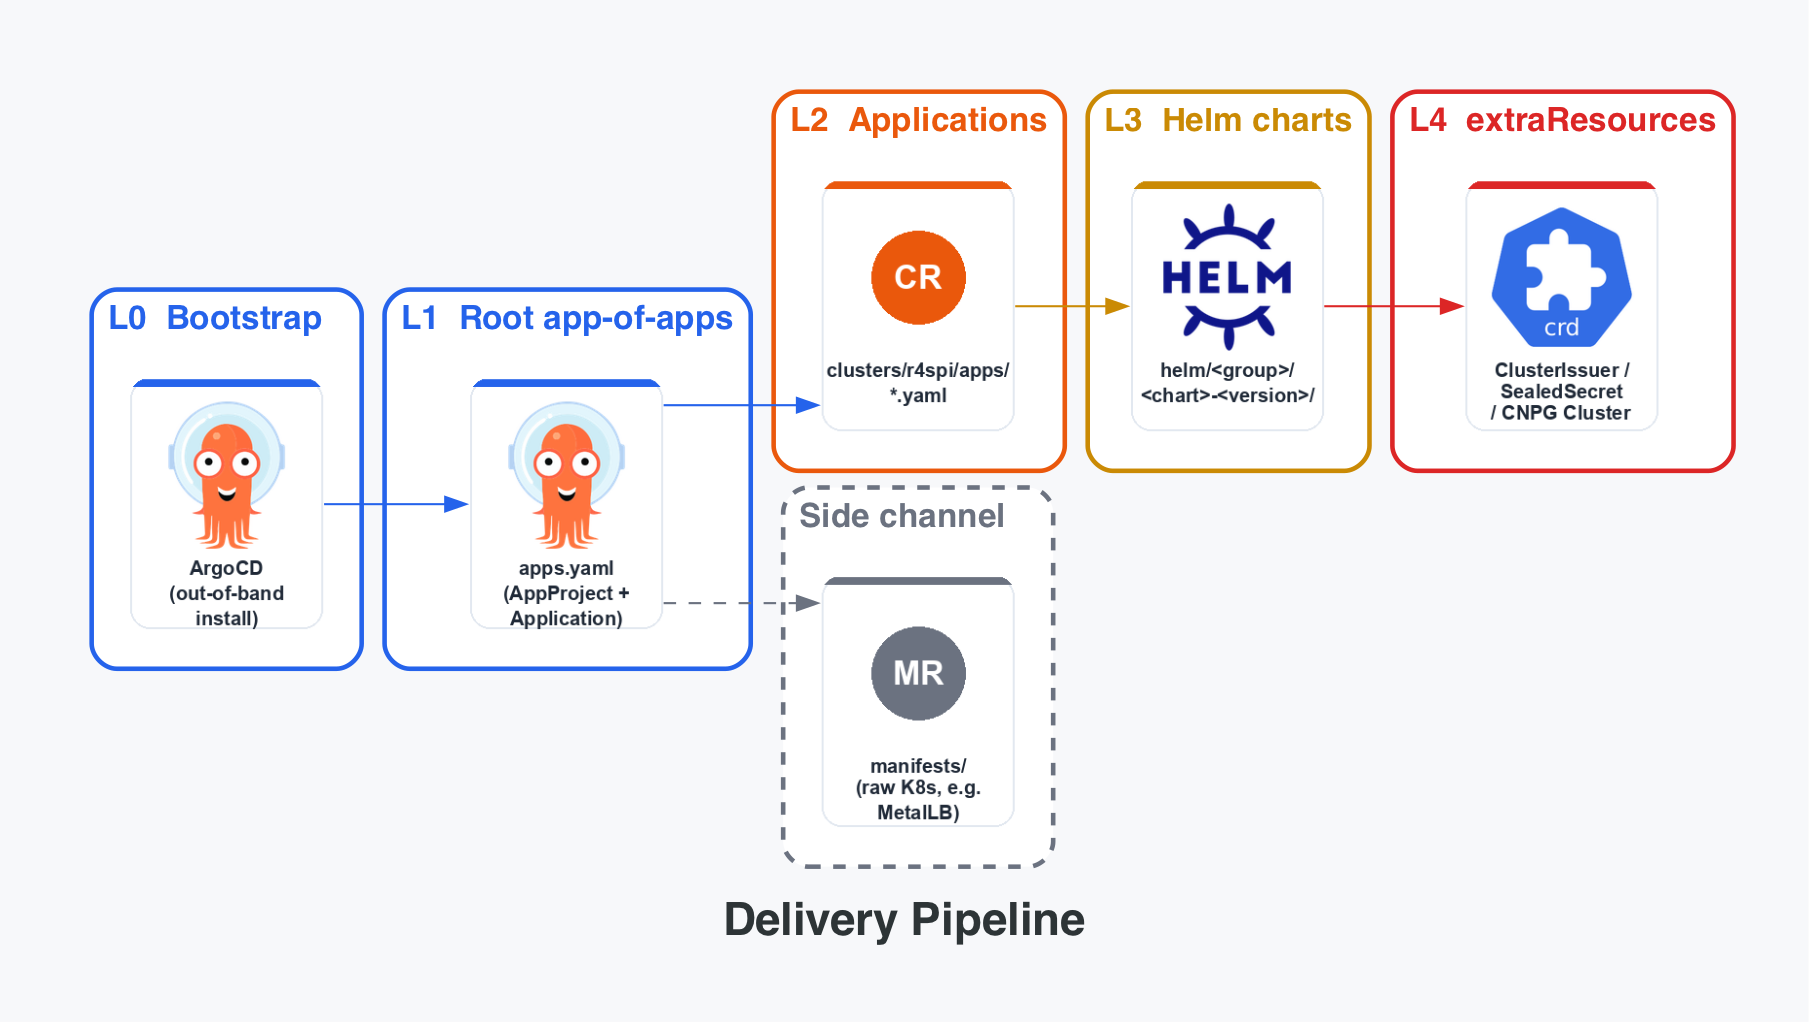

In [4]:
with Diagram(
    name="Delivery Pipeline",
    filename="delivery-pipeline",
    show=False,
    direction="LR",
    graph_attr={**TOP_GRAPH_ATTR, "splines": "ortho"},
    node_attr=NODE_ATTR,
) as diag:
    with layer_cluster("L0  Bootstrap", "gitops"):
        bootstrap = icon("ArgoCD\n(out-of-band install)", ARGOCD_ICON, "gitops")

    with layer_cluster("L1  Root app-of-apps", "gitops"):
        root = icon("apps.yaml\n(AppProject + Application)", ARGOCD_ICON, "gitops")

    with layer_cluster("L2  Applications", "edge"):
        app1 = text_icon("clusters/r4spi/apps/\n*.yaml", "edge")

    with layer_cluster("L3  Helm charts", "storage"):
        chart = icon("helm/<group>/\n<chart>-<version>/", HELM_ICON, "storage")

    with layer_cluster("L4  extraResources", "secrets"):
        extra = icon("ClusterIssuer / SealedSecret\n/ CNPG Cluster", CRD_ICON, "secrets")

    with layer_cluster("Side channel", "ops", dashed=True):
        manifests = text_icon("manifests/\n(raw K8s, e.g. MetalLB)", "ops")

    bootstrap >> Edge(color=COLOR["gitops"]) >> root
    root >> Edge(color=COLOR["gitops"]) >> app1
    app1 >> Edge(color=COLOR["storage"]) >> chart
    chart >> Edge(color=COLOR["secrets"]) >> extra
    root >> Edge(color=COLOR["ops"], style="dashed") >> manifests

diag